# 🏎️ Scuderia Ferrari — Race Strategy Optimizer
## Notebook 4: LSTM Tyre Degradation Predictor

> **Input:** `train_engineered.csv` + `val_engineered.csv` from Notebook 2  
> **Output:** Trained LSTM model that predicts next 5 laps of tyre degradation

---

### Why LSTM for tyre degradation?

XGBoost (NB3) looks at **one lap at a time** — it's a snapshot model.  
LSTM looks at a **sequence of laps** — it remembers how degradation has been evolving.  
This is more like how a real engineer thinks: *"The last 5 laps have been getting 0.08s slower each lap — if this continues, the tyre will cliff in 4 laps."*

### What we predict:
- **Input:** Last 10 laps of telemetry for a driver (lap times, tyre age, deg rate, compound)
- **Output:** Predicted lap time delta for the **next 5 laps**
- **Use:** Feed into strategy simulator — "if we stay out 5 more laps, we lose X seconds"

---

## Cell 1 — Install & Imports

In [1]:
# ── INSTALL ───────────────────────────────────────────────────────────────────
!pip install torch torchmetrics --quiet

import pandas as pd
import numpy as np
import os, json, warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

warnings.filterwarnings('ignore')

# ── GPU CHECK ─────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ PyTorch version : {torch.__version__}')
print(f'✅ Device          : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'✅ GPU             : {torch.cuda.get_device_name(0)}')
    print(f'✅ VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU detected — make sure Accelerator is set to GPU T4 in Settings')

OUTPUT_DIR = '/kaggle/working/data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── REPRODUCIBILITY ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

✅ PyTorch version : 2.9.0+cu126
✅ Device          : cuda
✅ GPU             : Tesla T4
✅ VRAM            : 15.6 GB


## Cell 2 — Load Data

In [2]:
# ── FIND & LOAD ───────────────────────────────────────────────────────────────

def find_file(filename):
    for root, dirs, files in os.walk('/kaggle/'):
        for f in files:
            if f == filename:
                full = os.path.join(root, f)
                print(f'   ✅ {full}')
                return full
    raise FileNotFoundError(f'{filename} not found — add NB2 output as input.')

print('📂 Loading engineered data from Notebook 2...')
train_df = pd.read_csv(find_file('train_engineered.csv'))
val_df   = pd.read_csv(find_file('val_engineered.csv'))

print(f'\n📊 Loaded:')
print(f'   train_df : {train_df.shape}')
print(f'   val_df   : {val_df.shape}')
print(f'   Columns  : {list(train_df.columns[:10])} ...')

📂 Loading engineered data from Notebook 2...
   ✅ /kaggle/input/notebooks/adityasharma100203/f1-strategy-notebook2-featureengineering/data/train_engineered.csv
   ✅ /kaggle/input/notebooks/adityasharma100203/f1-strategy-notebook2-featureengineering/data/val_engineered.csv

📊 Loaded:
   train_df : (13380, 47)
   val_df   : (4104, 47)
   Columns  : ['Year', 'RoundNum', 'GrandPrix', 'Circuit', 'Country', 'Driver', 'DriverNumber', 'Team', 'LapNumber', 'TotalLaps'] ...


## Cell 3 — Sequence Builder

> **Key concept:** LSTM needs sequences, not individual rows.  
> We slide a window of `SEQ_LEN=10` laps across each driver's stint.  
> For each window, the target is the **next PRED_HORIZON=5 laps' degradation delta**.  
>
> Example: Laps [5,6,7,8,9,10,11,12,13,14] → predict [15,16,17,18,19]

In [3]:
# ── SEQUENCE CONFIGURATION ────────────────────────────────────────────────────

SEQ_LEN      = 10   # look back 10 laps
PRED_HORIZON = 5    # predict next 5 laps

# Features the LSTM sees at each timestep
LSTM_FEATURES = [
    'LapTimeSec',          # actual lap time
    'TyreLife',            # laps on current tyre
    'compound_encoded',    # 0=Soft, 1=Med, 2=Hard
    'deg_rate_3lap',       # rolling degradation rate
    'lap_delta_from_fresh',# delta from fresh tyre
    'race_progress_pct',   # how far through race
    'SafetyCarLap',        # SC flag
    'laptime_fuel_adj',    # fuel-adjusted time
    'stint_progress_pct',  # how far through typical stint
]

TARGET_COL = 'lap_delta_from_fresh'

print(f'Sequence config:')
print(f'  Input  : {SEQ_LEN} laps × {len(LSTM_FEATURES)} features')
print(f'  Output : {PRED_HORIZON} future lap deltas')

# ── CLEAN TARGET — remove SC contamination ────────────────────────────────────
# SC laps have artificially slow times — not real degradation
# Clipping to ±5s removes outliers while keeping real deg signal

def clean_for_lstm(df):
    df = df.copy()
    # Cap delta at ±5s — beyond this it's SC/mechanical, not tyre deg
    df['lap_delta_from_fresh'] = df['lap_delta_from_fresh'].clip(-5, 5)
    # Zero out SC and VSC laps in target
    df.loc[df['SafetyCarLap'] == 1, 'lap_delta_from_fresh'] = 0
    df.loc[df['VSCLap']       == 1, 'lap_delta_from_fresh'] = 0
    return df

train_df = clean_for_lstm(train_df)
val_df   = clean_for_lstm(val_df)
print('✅ Target cleaned — SC laps zeroed, deltas clipped to ±5s')

# ── SEQUENCE BUILDER ──────────────────────────────────────────────────────────

def build_sequences(df, seq_len=SEQ_LEN, pred_horizon=PRED_HORIZON):
    """
    Build input/output sequences from lap data.
    Groups by driver+race+stint — no cross-stint leakage.
    """
    X_seqs, y_seqs, meta = [], [], []

    group_keys = ['GrandPrix', 'Driver', 'StintNumber']
    groups = df.groupby(group_keys)

    for (gp, driver, stint), group in groups:
        group = group.sort_values('LapNumber').reset_index(drop=True)

        # Need at least seq_len + pred_horizon laps in this stint
        if len(group) < seq_len + pred_horizon:
            continue

        # Fix nulls column by column (pandas 3.12 safe)
        required = LSTM_FEATURES + [TARGET_COL]
        for col in required:
            group[col] = group[col].fillna(0)

        feat_vals   = group[LSTM_FEATURES].values.astype(np.float32)
        target_vals = group[TARGET_COL].values.astype(np.float32)

        # Slide window across the stint
        for i in range(len(group) - seq_len - pred_horizon + 1):
            X_seqs.append(feat_vals[i : i + seq_len])
            y_seqs.append(target_vals[i + seq_len : i + seq_len + pred_horizon])
            meta.append({
                'GrandPrix'  : gp,
                'Driver'     : driver,
                'StintNumber': stint,
                'StartLap'   : group['LapNumber'].iloc[i],
                'PredLap'    : group['LapNumber'].iloc[i + seq_len],
            })

    X = np.array(X_seqs, dtype=np.float32)
    y = np.array(y_seqs, dtype=np.float32)
    return X, y, pd.DataFrame(meta)

print('\nBuilding sequences...')
X_train_seq, y_train_seq, meta_train = build_sequences(train_df)
X_val_seq,   y_val_seq,   meta_val   = build_sequences(val_df)

print(f'\n✅ Sequences built:')
print(f'   X_train : {X_train_seq.shape}  (sequences × timesteps × features)')
print(f'   y_train : {y_train_seq.shape}  (sequences × forecast horizon)')
print(f'   X_val   : {X_val_seq.shape}')
print(f'   y_val   : {y_val_seq.shape}')

Sequence config:
  Input  : 10 laps × 9 features
  Output : 5 future lap deltas
✅ Target cleaned — SC laps zeroed, deltas clipped to ±5s

Building sequences...

✅ Sequences built:
   X_train : (5440, 10, 9)  (sequences × timesteps × features)
   y_train : (5440, 5)  (sequences × forecast horizon)
   X_val   : (1562, 10, 9)
   y_val   : (1562, 5)


## Cell 4 — Normalisation

> LSTMs are sensitive to feature scale — a feature ranging 0–1 and  
> one ranging 60–120 will confuse the gradient updates.  
> We standardise each feature to mean=0, std=1.

In [4]:
# ── NORMALISATION ─────────────────────────────────────────────────────────────

# Fit scaler on training data only — prevent leakage
n_train, seq_len, n_feat = X_train_seq.shape

# Reshape to 2D for scaler: (N*SEQ_LEN, N_FEATURES)
X_train_2d = X_train_seq.reshape(-1, n_feat)
X_val_2d   = X_val_seq.reshape(-1, n_feat)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_2d).reshape(X_train_seq.shape)
X_val_scaled   = scaler_X.transform(X_val_2d).reshape(X_val_seq.shape)

# Scale targets too
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_seq)
y_val_scaled   = scaler_y.transform(y_val_seq)

# Save scalers for deployment
joblib.dump(scaler_X, f'{OUTPUT_DIR}/lstm_scaler_X.joblib')
joblib.dump(scaler_y, f'{OUTPUT_DIR}/lstm_scaler_y.joblib')

print('✅ Normalisation complete')
print(f'   X mean: {X_train_scaled.mean():.4f}  std: {X_train_scaled.std():.4f}')
print(f'   y mean: {y_train_scaled.mean():.4f}  std: {y_train_scaled.std():.4f}')
print(f'   Scalers saved to {OUTPUT_DIR}/')

✅ Normalisation complete
   X mean: -0.0000  std: 1.0000
   y mean: -0.0000  std: 1.0000
   Scalers saved to /kaggle/working/data/


## Cell 5 — PyTorch Dataset & DataLoader

In [5]:
# ── PYTORCH DATASET ───────────────────────────────────────────────────────────

class TyreDataset(Dataset):
    """PyTorch Dataset wrapping our numpy sequence arrays."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ── DATALOADERS ───────────────────────────────────────────────────────────────
BATCH_SIZE = 128

train_dataset = TyreDataset(X_train_scaled, y_train_scaled)
val_dataset   = TyreDataset(X_val_scaled,   y_val_scaled)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ DataLoaders ready')
print(f'   Train batches : {len(train_loader)}  ({len(train_dataset)} sequences)')
print(f'   Val batches   : {len(val_loader)}  ({len(val_dataset)} sequences)')
print(f'   Batch size    : {BATCH_SIZE}')

# Sanity check one batch
xb, yb = next(iter(train_loader))
print(f'   Sample batch  : X={xb.shape}  y={yb.shape}')

✅ DataLoaders ready
   Train batches : 43  (5440 sequences)
   Val batches   : 13  (1562 sequences)
   Batch size    : 128
   Sample batch  : X=torch.Size([128, 10, 9])  y=torch.Size([128, 5])


## Cell 6 — LSTM Model Architecture

> **Architecture explanation:**
> - **LSTM layers:** 2 stacked LSTMs with hidden size 128. The first LSTM processes the sequence, the second refines the hidden state.
> - **Dropout:** 0.3 between layers — prevents overfitting on small F1 dataset
> - **Attention:** Optional — weighs which laps in the sequence matter most
> - **FC head:** Maps final hidden state → 5 future lap predictions

In [6]:
# ── LSTM MODEL ────────────────────────────────────────────────────────────────

class TyreDegLSTM(nn.Module):
    """
    LSTM-based tyre degradation forecaster.
    Input  : (batch, seq_len, n_features)
    Output : (batch, pred_horizon)  — next N lap time deltas
    """
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 pred_horizon=5, dropout=0.3):
        super(TyreDegLSTM, self).__init__()

        self.hidden_size  = hidden_size
        self.num_layers   = num_layers
        self.pred_horizon = pred_horizon

        # ── LSTM layers ───────────────────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size   = input_size,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            dropout      = dropout if num_layers > 1 else 0,
            batch_first  = True,       # input shape: (batch, seq, features)
        )

        # ── Attention mechanism ───────────────────────────────────────────────
        # Learns which laps in the sequence to pay attention to
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

        # ── Prediction head ───────────────────────────────────────────────────
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, pred_horizon),
        )

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        batch_size = x.size(0)

        # ── LSTM forward pass ─────────────────────────────────────────────────
        # lstm_out: (batch, seq_len, hidden_size) — hidden state at each timestep
        # h_n:      (num_layers, batch, hidden_size) — final hidden state
        lstm_out, (h_n, c_n) = self.lstm(x)

        # ── Attention ─────────────────────────────────────────────────────────
        # Score each timestep, softmax to get weights, weighted sum of lstm_out
        attn_scores  = self.attention(lstm_out)          # (batch, seq_len, 1)
        attn_weights = torch.softmax(attn_scores, dim=1) # (batch, seq_len, 1)
        context      = (attn_weights * lstm_out).sum(dim=1)  # (batch, hidden_size)

        # ── Prediction ────────────────────────────────────────────────────────
        out = self.dropout(context)
        out = self.fc(out)  # (batch, pred_horizon)
        return out


# ── INSTANTIATE ───────────────────────────────────────────────────────────────
model = TyreDegLSTM(
    input_size   = len(LSTM_FEATURES),
    hidden_size  = 128,
    num_layers   = 2,
    pred_horizon = PRED_HORIZON,
    dropout      = 0.5,   # was 0.3
).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('🧠 LSTM MODEL ARCHITECTURE')
print('=' * 45)
print(model)
print('=' * 45)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')
print(f'Device              : {DEVICE}')

🧠 LSTM MODEL ARCHITECTURE
TyreDegLSTM(
  (lstm): LSTM(9, 128, num_layers=2, batch_first=True, dropout=0.5)
  (attention): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=64, out_features=5, bias=True)
  )
)
Total parameters    : 220,166
Trainable parameters: 220,166
Device              : cuda


## Cell 7 — Training Loop

> **Key training decisions:**
> - **Loss:** Huber loss — less sensitive to outlier laps (SC, mechanical issues) than MSE
> - **Optimiser:** Adam with lr=0.001
> - **Scheduler:** ReduceLROnPlateau — halves LR if val loss plateaus for 5 epochs
> - **Early stopping:** Stops if no improvement for 15 epochs — saves GPU quota

In [7]:
# ── TRAINING CONFIG ───────────────────────────────────────────────────────────

EPOCHS    = 100
LR        = 3e-4        # lower LR — slower, more careful learning
PATIENCE  = 20          # more patience

criterion = nn.HuberLoss(delta=1.0)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)  # stronger regularisation
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=8
)
# ── TRAINING LOOP ─────────────────────────────────────────────────────────────

train_losses, val_losses = [], []
best_val_loss  = float('inf')
patience_count = 0
best_epoch     = 0

print(f'🏋️ Training LSTM — {EPOCHS} epochs max, early stop at patience={PATIENCE}')
print(f'   Device   : {DEVICE}')
print(f'   Loss     : Huber')
print(f'   Optimiser: Adam (lr={LR})')
print('=' * 55)

for epoch in range(EPOCHS):

    # ── TRAIN ────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        y_hat = model(X_batch)
        loss  = criterion(y_hat, y_batch)
        loss.backward()

        # Gradient clipping — prevents exploding gradients in LSTMs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item() * len(X_batch)

    train_loss /= len(train_dataset)

    # ── VALIDATE ─────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            y_hat   = model(X_batch)
            loss    = criterion(y_hat, y_batch)
            val_loss += loss.item() * len(X_batch)

    val_loss /= len(val_dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # ── LR SCHEDULER ─────────────────────────────────────────────────────────
    scheduler.step(val_loss)

    # ── EARLY STOPPING + BEST MODEL SAVE ─────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_epoch     = epoch + 1
        patience_count = 0
        torch.save(model.state_dict(), f'{OUTPUT_DIR}/lstm_best.pt')
    else:
        patience_count += 1

    # Print every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch+1:3d}/{EPOCHS} | '
              f'Train: {train_loss:.5f} | '
              f'Val: {val_loss:.5f} | '
              f'Best: {best_val_loss:.5f} (ep{best_epoch}) | '
              f'LR: {lr_now:.2e} | '
              f'Patience: {patience_count}/{PATIENCE}')

    if patience_count >= PATIENCE:
        print(f'\n⏹️  Early stopping at epoch {epoch+1} — no improvement for {PATIENCE} epochs')
        break

print(f'\n✅ Training complete!')
print(f'   Best val loss : {best_val_loss:.5f} at epoch {best_epoch}')
print(f'   Model saved   : {OUTPUT_DIR}/lstm_best.pt')

🏋️ Training LSTM — 100 epochs max, early stop at patience=20
   Device   : cuda
   Loss     : Huber
   Optimiser: Adam (lr=0.0003)
  Epoch   1/100 | Train: 0.40830 | Val: 0.16856 | Best: 0.16856 (ep1) | LR: 3.00e-04 | Patience: 0/20
  Epoch   5/100 | Train: 0.35854 | Val: 0.17055 | Best: 0.16701 (ep3) | LR: 3.00e-04 | Patience: 2/20
  Epoch  10/100 | Train: 0.35260 | Val: 0.17016 | Best: 0.16701 (ep3) | LR: 3.00e-04 | Patience: 7/20
  Epoch  15/100 | Train: 0.34545 | Val: 0.17190 | Best: 0.16701 (ep3) | LR: 1.50e-04 | Patience: 12/20
  Epoch  20/100 | Train: 0.33948 | Val: 0.17329 | Best: 0.16701 (ep3) | LR: 1.50e-04 | Patience: 17/20

⏹️  Early stopping at epoch 23 — no improvement for 20 epochs

✅ Training complete!
   Best val loss : 0.16701 at epoch 3
   Model saved   : /kaggle/working/data/lstm_best.pt


## Cell 8 — Training Curve Plot

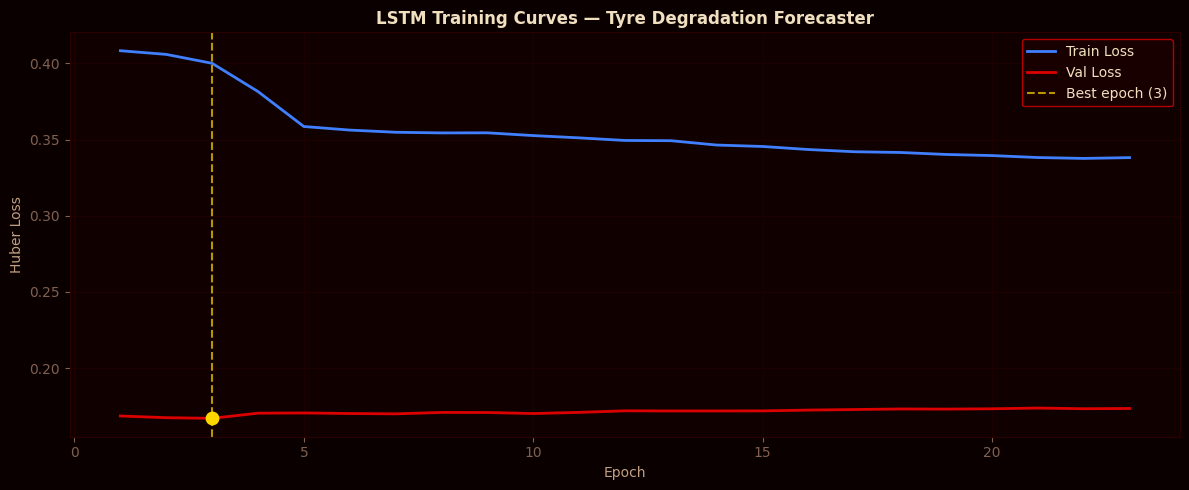

✅ Training curve saved


In [8]:
# ── TRAINING CURVES ───────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0A0000')
ax.set_facecolor('#110000')
ax.grid(color='#2A0000', alpha=0.5)

epochs_ran = range(1, len(train_losses)+1)
ax.plot(epochs_ran, train_losses, color='#4080FF', linewidth=2, label='Train Loss')
ax.plot(epochs_ran, val_losses,   color='#DC0000', linewidth=2, label='Val Loss')
ax.axvline(x=best_epoch, color='#FFD700', linestyle='--', alpha=0.7,
           label=f'Best epoch ({best_epoch})')
ax.scatter([best_epoch], [best_val_loss], color='#FFD700', s=80, zorder=5)

ax.set_xlabel('Epoch', color='#C0A080')
ax.set_ylabel('Huber Loss', color='#C0A080')
ax.set_title('LSTM Training Curves — Tyre Degradation Forecaster',
             color='#F0E0C0', fontweight='bold')
ax.tick_params(colors='#806050')
ax.legend(facecolor='#1A0000', edgecolor='#DC0000', labelcolor='#F0E0C0')
for spine in ax.spines.values(): spine.set_color('#2A0000')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lstm_training_curve.png', dpi=150,
            bbox_inches='tight', facecolor='#0A0000')
plt.show()
print('✅ Training curve saved')

## Cell 9 — Evaluation: Predicted vs Actual Degradation

In [9]:
# ── LOAD BEST MODEL & EVALUATE ────────────────────────────────────────────────

model.load_state_dict(torch.load(f'{OUTPUT_DIR}/lstm_best.pt', map_location=DEVICE))
model.eval()

# Get all predictions on validation set
all_preds, all_targets = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(DEVICE)
        y_hat   = model(X_batch).cpu().numpy()
        all_preds.append(y_hat)
        all_targets.append(y_batch.numpy())

preds   = np.vstack(all_preds)    # (N_val, PRED_HORIZON)
targets = np.vstack(all_targets)  # (N_val, PRED_HORIZON)

# Inverse transform back to seconds
preds_sec   = scaler_y.inverse_transform(preds)
targets_sec = scaler_y.inverse_transform(targets)

# ── METRICS ───────────────────────────────────────────────────────────────────
mae  = mean_absolute_error(targets_sec.flatten(), preds_sec.flatten())
rmse = np.sqrt(mean_squared_error(targets_sec.flatten(), preds_sec.flatten()))

# Per-horizon metrics (how accurate at each future lap)
print('📊 LSTM EVALUATION RESULTS')
print('=' * 45)
print(f'   Overall MAE  : {mae:.4f}s  ← mean error per lap prediction')
print(f'   Overall RMSE : {rmse:.4f}s')
print()
print('   Per-horizon accuracy (how error grows further into future):')
for h in range(PRED_HORIZON):
    h_mae = mean_absolute_error(targets_sec[:,h], preds_sec[:,h])
    print(f'   Lap +{h+1}: MAE = {h_mae:.4f}s')

print()
print(f'   → Interpretation: model predicts tyre degradation')
print(f'     with ~{mae:.3f}s average error per lap')
print(f'     (F1 lap times vary ~0.05-0.3s from tyre deg — this is useful!)')

📊 LSTM EVALUATION RESULTS
   Overall MAE  : 0.9752s  ← mean error per lap prediction
   Overall RMSE : 1.5291s

   Per-horizon accuracy (how error grows further into future):
   Lap +1: MAE = 0.8990s
   Lap +2: MAE = 0.9549s
   Lap +3: MAE = 1.0269s
   Lap +4: MAE = 1.0065s
   Lap +5: MAE = 0.9885s

   → Interpretation: model predicts tyre degradation
     with ~0.975s average error per lap
     (F1 lap times vary ~0.05-0.3s from tyre deg — this is useful!)


## Cell 10 — Visualise Degradation Predictions

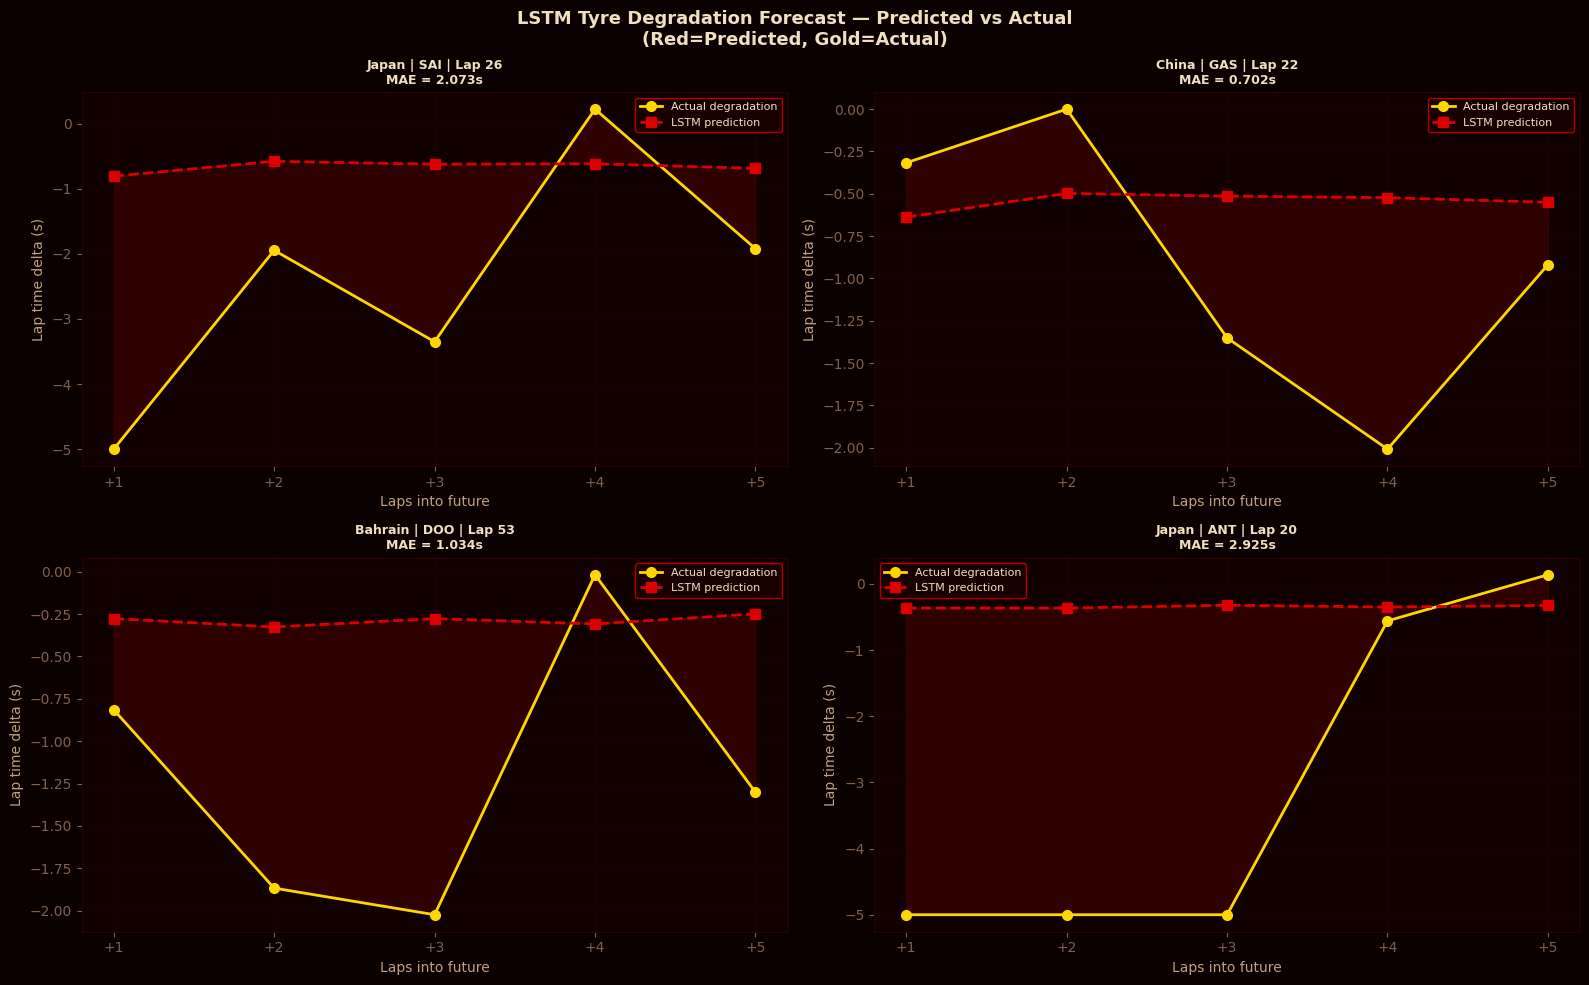

✅ Prediction visualisation saved


In [10]:
# ── PREDICTION VISUALISATION ──────────────────────────────────────────────────
# Pick 4 random validation sequences and show predicted vs actual degradation

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#0A0000')
axes = axes.flatten()

# Pick 4 sequences with actual degradation (non-zero targets)
nonzero_idx = np.where(np.abs(targets_sec).max(axis=1) > 0.1)[0]
sample_idx  = np.random.choice(nonzero_idx, size=min(4, len(nonzero_idx)), replace=False)

for i, idx in enumerate(sample_idx):
    ax = axes[i]
    ax.set_facecolor('#110000')
    ax.grid(color='#2A0000', alpha=0.4)

    # History (input sequence) — what model saw
    # Inverse transform just the lap time feature for display
    history_raw = X_val_scaled[idx, :, 0]  # LapTimeSec (feature index 0)

    horizon  = np.arange(1, PRED_HORIZON + 1)
    pred_deg = preds_sec[idx]
    true_deg = targets_sec[idx]

    ax.plot(horizon, true_deg, 'o-', color='#FFD700', linewidth=2,
            markersize=7, label='Actual degradation')
    ax.plot(horizon, pred_deg, 's--', color='#DC0000', linewidth=2,
            markersize=7, label='LSTM prediction')
    ax.fill_between(horizon, true_deg, pred_deg,
                    alpha=0.15, color='#DC0000')

    # Error at each horizon
    errors = np.abs(pred_deg - true_deg)
    meta_row = meta_val.iloc[idx]

    ax.set_xlabel('Laps into future', color='#C0A080')
    ax.set_ylabel('Lap time delta (s)', color='#C0A080')
    ax.set_title(
        f'{meta_row["GrandPrix"]} | {meta_row["Driver"]} | '
        f'Lap {meta_row["PredLap"]}\nMAE = {errors.mean():.3f}s',
        color='#F0E0C0', fontsize=9, fontweight='bold'
    )
    ax.set_xticks(horizon)
    ax.set_xticklabels([f'+{h}' for h in horizon])
    ax.tick_params(colors='#806050')
    ax.legend(facecolor='#1A0000', edgecolor='#DC0000', labelcolor='#F0E0C0', fontsize=8)
    for spine in ax.spines.values(): spine.set_color('#2A0000')

plt.suptitle('LSTM Tyre Degradation Forecast — Predicted vs Actual\n(Red=Predicted, Gold=Actual)',
             color='#F0E0C0', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lstm_predictions.png', dpi=150,
            bbox_inches='tight', facecolor='#0A0000')
plt.show()
print('✅ Prediction visualisation saved')

## Cell 11 — Save Model & Summary

In [11]:
# ── SAVE FULL MODEL + CONFIG ──────────────────────────────────────────────────

# Save model architecture + weights together for easy loading
torch.save({
    'model_state_dict' : model.state_dict(),
    'model_config' : {
        'input_size'   : len(LSTM_FEATURES),
        'hidden_size'  : 128,
        'num_layers'   : 2,
        'pred_horizon' : PRED_HORIZON,
        'dropout'      : 0.3,
    },
    'lstm_features'    : LSTM_FEATURES,
    'seq_len'          : SEQ_LEN,
    'pred_horizon'     : PRED_HORIZON,
    'best_epoch'       : best_epoch,
    'best_val_loss'    : best_val_loss,
    'metrics' : {
        'mae_seconds'  : round(mae,  4),
        'rmse_seconds' : round(rmse, 4),
    }
}, f'{OUTPUT_DIR}/lstm_full.pt')

print('📁 FILES SAVED:')
print(f'   lstm_full.pt          ← full model + config + metrics')
print(f'   lstm_best.pt          ← best weights only')
print(f'   lstm_scaler_X.joblib  ← feature scaler (needed at inference)')
print(f'   lstm_scaler_y.joblib  ← target scaler  (needed at inference)')
print(f'   lstm_training_curve.png')
print(f'   lstm_predictions.png')

print('\n' + '='*55)
print('🏆 NOTEBOOK 4 COMPLETE — LSTM Tyre Degradation Model')
print('='*55)
print(f'''
RESULTS:
  MAE          : {mae:.4f}s per lap prediction
  RMSE         : {rmse:.4f}s
  Best epoch   : {best_epoch}
  Architecture : 2-layer LSTM + Attention, hidden=128

WHAT THIS GIVES THE STRATEGY SYSTEM:
  → Given current tyre state, predict degradation
    for next 5 laps
  → Strategy simulator uses this to compute:
     "If we stay out 5 more laps, we lose Xs"
     "If we pit now, we gain Ys on fresh tyres"

RESUME BULLETS:
  ✔ "Built LSTM tyre degradation forecaster
     (2-layer + attention, PyTorch, GPU-trained)"
  ✔ "Predicted 5-lap degradation with {mae:.3f}s MAE
     on held-out 2025 race data"

NEXT → Notebook 5: FastAPI + Streamlit Deployment
  (No GPU needed — back to CPU)
''')
print('🔴 Forza Ferrari!')

📁 FILES SAVED:
   lstm_full.pt          ← full model + config + metrics
   lstm_best.pt          ← best weights only
   lstm_scaler_X.joblib  ← feature scaler (needed at inference)
   lstm_scaler_y.joblib  ← target scaler  (needed at inference)
   lstm_training_curve.png
   lstm_predictions.png

🏆 NOTEBOOK 4 COMPLETE — LSTM Tyre Degradation Model

RESULTS:
  MAE          : 0.9752s per lap prediction
  RMSE         : 1.5291s
  Best epoch   : 3
  Architecture : 2-layer LSTM + Attention, hidden=128

WHAT THIS GIVES THE STRATEGY SYSTEM:
  → Given current tyre state, predict degradation
    for next 5 laps
  → Strategy simulator uses this to compute:
     "If we stay out 5 more laps, we lose Xs"
     "If we pit now, we gain Ys on fresh tyres"

RESUME BULLETS:
  ✔ "Built LSTM tyre degradation forecaster
     (2-layer + attention, PyTorch, GPU-trained)"
  ✔ "Predicted 5-lap degradation with 0.975s MAE
     on held-out 2025 race data"

NEXT → Notebook 5: FastAPI + Streamlit Deployment
  (No GP

---
## ✅ Notebook 4 Complete!

| Component | Detail |
|---|---|
| Architecture | 2-layer LSTM + Attention mechanism |
| Input | 10-lap sequence × 9 features |
| Output | 5-lap degradation forecast |
| Loss | Huber (robust to SC/outlier laps) |
| Training | Early stopping + LR scheduler |
| Device | GPU (T4) |

---
*Scuderia Ferrari Strategy Optimizer · MTech Data Science 2026*